# Car Color Classifier ResNet

## Imports

In [1]:
import os
import shutil
import zipfile
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import ResNet50
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from PIL import Image
from google.colab import drive

## Parameters

In [2]:
ZIP_PATH = "/content/drive/MyDrive/Confirmed_fronts.zip"
PATH = '/content/confirmed_fronts'
NEW_PATH = '/content/confirmed_fronts_new'
IMAGE_SIZE = (180, 180)
IMAGE_SHAPE = (180, 180, 3)
BATCH_SIZE = 32

## Dataset

### Load from Drive

In [3]:
drive.mount('/content/drive')

if not os.path.isdir(PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(".")

Mounted at /content/drive


### Restructuring

As is car images were grouped by manufacturer and production year. We want to group images by color, which is in the name of each image.

In [4]:
def restructure(root_dir, new_dir):
    for subdir, _, files in os.walk(root_dir):
        for f in files:
            try:
                color = f.split('$$')[3].strip().lower()

                target_dir = os.path.join(new_dir, color)
                os.makedirs(target_dir, exist_ok=True)

                copy_from = os.path.join(subdir, f)
                copy_to = os.path.join(target_dir, f)
                shutil.copy(copy_from, copy_to)

            except Exception as e:
                print(f"Error with {f}: {str(e)}")
                continue


restructure(PATH, NEW_PATH)

### Cleanup

In [6]:
def get_classes(root_dir, min_elements):
    class_counts = {}

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)

        if os.path.isdir(class_path):
            file_count = len(os.listdir(class_path))
            class_counts[class_name] = file_count

    return class_counts


classes = get_classes(NEW_PATH, 2000)

### Class distribution

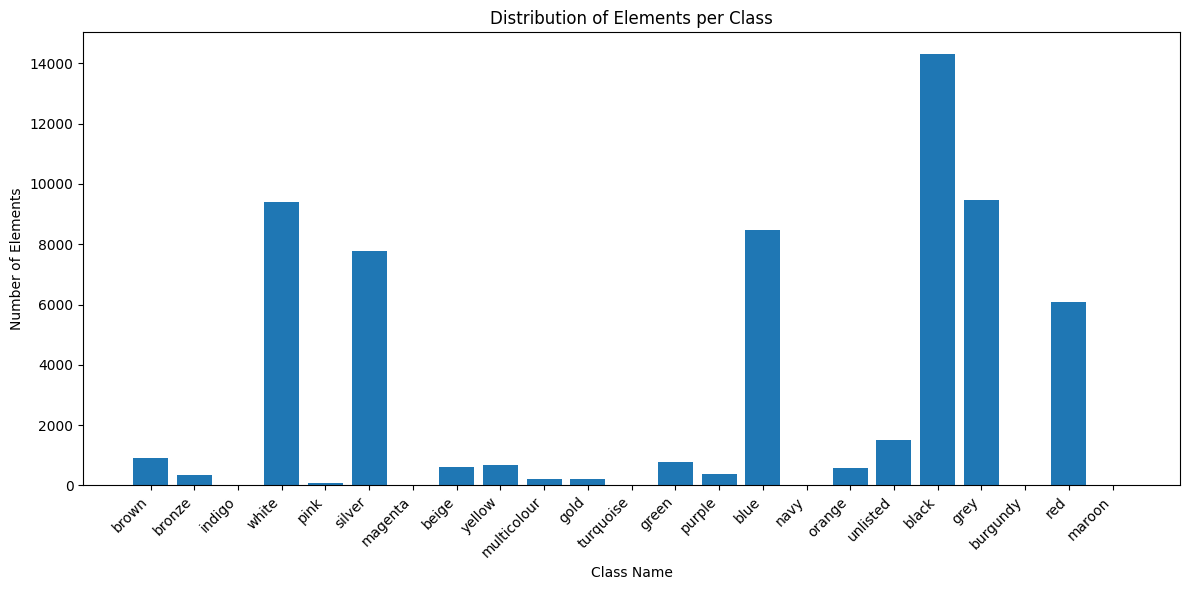

In [7]:
names = list(classes.keys())
values = list(classes.values())

plt.figure(figsize=(12, 6))
plt.bar(names, values)
plt.xlabel("Class Name")
plt.ylabel("Number of Elements")
plt.title("Distribution of Elements per Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [8]:
def process_classes(root_dir, min_elements):
    class_counts = {}

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)

        if os.path.isdir(class_path):
            file_count = len(os.listdir(class_path))
            print(f"Class: {class_name}, Elements: {file_count}")

            if file_count >= min_elements:
                class_counts[class_name] = file_count
            else:
                print(f"  Removing class '{class_name}' (elements < {min_elements})")
                shutil.rmtree(class_path)

    return class_counts


classes = process_classes(NEW_PATH, 2000)

Class: brown, Elements: 911
  Removing class 'brown' (elements < 2000)
Class: bronze, Elements: 329
  Removing class 'bronze' (elements < 2000)
Class: indigo, Elements: 1
  Removing class 'indigo' (elements < 2000)
Class: white, Elements: 9395
Class: pink, Elements: 87
  Removing class 'pink' (elements < 2000)
Class: silver, Elements: 7770
Class: magenta, Elements: 9
  Removing class 'magenta' (elements < 2000)
Class: beige, Elements: 600
  Removing class 'beige' (elements < 2000)
Class: yellow, Elements: 667
  Removing class 'yellow' (elements < 2000)
Class: multicolour, Elements: 196
  Removing class 'multicolour' (elements < 2000)
Class: gold, Elements: 217
  Removing class 'gold' (elements < 2000)
Class: turquoise, Elements: 26
  Removing class 'turquoise' (elements < 2000)
Class: green, Elements: 777
  Removing class 'green' (elements < 2000)
Class: purple, Elements: 362
  Removing class 'purple' (elements < 2000)
Class: blue, Elements: 8483
Class: navy, Elements: 1
  Removing cla

### Train/val, resize, reshape

In [9]:
x_train, x_val = tf.keras.utils.image_dataset_from_directory(
    NEW_PATH,
    validation_split=0.2,
    subset="both",
    seed=42,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE
)

Found 55534 files belonging to 6 classes.
Using 44428 files for training.
Using 11106 files for validation.


## The Net

In [14]:
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=IMAGE_SHAPE)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(1024, activation="relu")(x)
predictions = layers.Dense(len(classes.keys()), activation="softmax")(x)
model = models.Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=optimizers.Adam(), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.fit(x_train, epochs=10)

Epoch 1/10
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 89s 58ms/step - accuracy: 0.6657 - loss: 0.9488
Epoch 2/10
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 137s 56ms/step - accuracy: 0.7789 - loss: 0.5866
Epoch 3/10
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 83s 57ms/step - accuracy: 0.8002 - loss: 0.5314
Epoch 4/10
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 80s 58ms/step - accuracy: 0.8128 - loss: 0.4999
Epoch 5/10
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 82s 58ms/step - accuracy: 0.8249 - loss: 0.4685
Epoch 6/10
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 80s 58ms/step - accuracy: 0.8367 - loss: 0.4380
Epoch 7/10
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 82s 58ms/step - accuracy: 0.8455 - loss: 0.4130
Epoch 8/10
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 81s 58ms/step - accuracy: 0.8554 - loss: 0.3908
Epoch 9/10
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 81s 58ms/step - accuracy: 0.8644 - loss: 0.3721
Epoch 10/10
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 81s 58ms/step - accuracy: 0.8728 - loss: 0.3453


In [15]:
val_predictions = model.predict(x_val)
val_predicted_labels = np.argmax(val_predictions, axis=1)

348/348 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step


## Validation

### F1 macro

In [16]:
labels = x_val.class_names
true_val_labels = []
for _, label in x_val:
    true_val_labels.extend(label.numpy())

true_val_labels = np.array(true_val_labels)
f1_macro = f1_score(true_val_labels, val_predicted_labels, average="macro")
print(f"F1 Macro Score: {f1_macro}")

F1 Macro Score: 0.8183012529637947


### Confusion Matrix

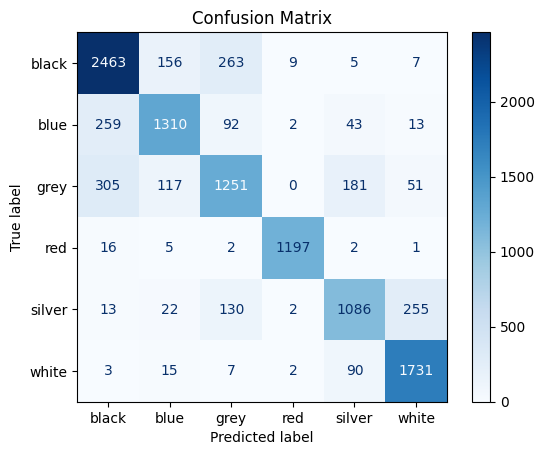

In [17]:
cm = confusion_matrix(true_val_labels, val_predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()